In [1]:
!pip install -U scikit-learn imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 90.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 10.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 

In [2]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.7.2
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.11/dist-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: bayesian-optimization, Boruta, category_encoders, cesium, eli5, fastai, hdbscan, hep_ml, imbalanced-learn, librosa, lime, mlxtend, nilearn, pyLDAvis, pynndescent, rgf-python, scikit-learn-intelex, scikit-optimize, scikit-plot, sentence-transformers, shap, sklearn-compat, sklearn-pandas, TPOT, tsfresh, umap-learn, woodwork, yellowbrick


In [4]:
import pandas as pd
import numpy as np
import os
import glob
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, Dropout, Flatten, Reshape
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

print("GPU Available:", tf.config.list_physical_devices('GPU'))
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True)

data_path = '/kaggle/input/network-intrusion-dataset'
csv_files = glob.glob(os.path.join(data_path, '*.csv'))
print("Found CSV files:", len(csv_files))

dataframes = []
for file in csv_files:
    df = pd.read_csv(file)
    print(f"File: {os.path.basename(file)} - Shape: {df.shape}")
    dataframes.append(df)

combined_df = pd.concat(dataframes, ignore_index=True)
print(f"Combined dataset shape: {combined_df.shape}")
print(f"All columns: {combined_df.columns.tolist()}")
label_col = combined_df.columns[-1]
print(f"Label column: '{label_col}'")
print(f"Label distribution:\n{combined_df[label_col].value_counts()}")

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found CSV files: 8
File: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv - Shape: (286467, 79)
File: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv - Shape: (170366, 79)
File: Tuesday-WorkingHours.pcap_ISCX.csv - Shape: (445909, 79)
File: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv - Shape: (225745, 79)
File: Monday-WorkingHours.pcap_ISCX.csv - Shape: (529918, 79)
File: Friday-WorkingHours-Morning.pcap_ISCX.csv - Shape: (191033, 79)
File: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv - Shape: (288602, 79)
File: Wednesday-workingHours.pcap_ISCX.csv - Shape: (692703, 79)
Combined dataset shape: (2830743, 79)
All columns: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'B

In [5]:
df = combined_df.copy()
label_col = ' Label'

print("Initial data info:")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

df.columns = df.columns.str.strip()
label_col = 'Label'

print("\nHandling infinite and missing values...")
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(0)

print("Encoding categorical features...")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if label_col in categorical_cols:
    categorical_cols.remove(label_col)

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoding target labels...")
le_target = LabelEncoder()
df['Label_encoded'] = le_target.fit_transform(df[label_col])
num_classes = len(le_target.classes_)

print(f"Number of classes: {num_classes}")
print(f"Classes: {le_target.classes_}")
print(f"Encoded label distribution:\n{df['Label_encoded'].value_counts().sort_index()}")

X = df.drop([label_col, 'Label_encoded'], axis=1)
y = df['Label_encoded']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Initial data info:
Shape: (2830743, 79)
Missing values: 1358

Handling infinite and missing values...
Encoding categorical features...
Encoding target labels...
Number of classes: 15
Classes: ['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']
Encoded label distribution:
Label_encoded
0     2273097
1        1966
2      128027
3       10293
4      231073
5        5499
6        5796
7        7938
8          11
9          36
10     158930
11       5897
12       1507
13         21
14        652
Name: count, dtype: int64
Features shape: (2830743, 78)
Target shape: (2830743,)


In [7]:
print("Scaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

y_train = y_train.values
y_test = y_test.values

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

print("\nOriginal class distribution in training:")
unique, counts = np.unique(y_train, return_counts=True)
for i, (cls, count) in enumerate(zip(unique, counts)):
    print(f"Class {cls}: {count}")

seq_length = 5

def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    step_size = seq_length
    for i in range(0, len(X) - seq_length + 1, step_size):
        X_seq.append(X[i:(i + seq_length)])
        y_seq.append(y[i + seq_length - 1])
    return np.array(X_seq), np.array(y_seq)

print(f"\nCreating sequences with length {seq_length}...")
X_train_seq, y_train_seq = create_sequences(X_train, y_train, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, seq_length)

print(f"Training sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")
print(f"Number of classes: {len(np.unique(y_train_seq))}")

Scaling features...
Splitting data...
Training set: (2264594, 78)
Test set: (566149, 78)

Original class distribution in training:
Class 0: 1818477
Class 1: 1573
Class 2: 102421
Class 3: 8234
Class 4: 184858
Class 5: 4399
Class 6: 4637
Class 7: 6350
Class 8: 9
Class 9: 29
Class 10: 127144
Class 11: 4718
Class 12: 1206
Class 13: 17
Class 14: 522

Creating sequences with length 5...
Training sequences: (452918, 5, 78)
Test sequences: (113229, 5, 78)
Number of classes: 14


In [9]:
num_classes = 15

model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(seq_length, n_features)),
    Dropout(0.2),
    
    Conv1D(filters=128, kernel_size=2, activation='relu'),
    Dropout(0.3),
    
    LSTM(100, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    LSTM(50, dropout=0.2, recurrent_dropout=0.2),
    
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print(f"Training sequences shape: {X_train_seq.shape}")
print(f"Training labels shape: {y_train_seq.shape}")
print(f"Test sequences shape: {X_test_seq.shape}")
print(f"Test labels shape: {y_test_seq.shape}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 4, 64)          │        10,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 3, 128)         │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 3, 100)         │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,119 (641.09 KB)

 Trainable params: 164,119 (641.09 KB)

 Non-trainable params: 0 (0.00 B)

Training sequences shape: (452918, 5, 78)
Training labels shape: (452918,)
Test sequences shape: (113229, 5, 78)
Test labels shape: (113229,)


In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint('best_cnn_lstm_model.h5', monitor='val_accuracy', save_best_only=True)
]

print("Starting model training...")
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=20,
    batch_size=1024,
    validation_data=(X_test_seq, y_test_seq),
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")
print("Loading best model...")
model.load_weights('best_cnn_lstm_model.h5')

test_loss, test_accuracy = model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

Starting model training...
Epoch 1/20


I0000 00:00:1764850198.041570     121 cuda_dnn.cc:529] Loaded cuDNN version 90300


443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7805 - loss: 0.8999

443/443 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.7807 - loss: 0.8990 - val_accuracy: 0.9138 - val_loss: 0.2194 - learning_rate: 0.0010
Epoch 2/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9356 - loss: 0.2123

443/443 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9357 - loss: 0.2122 - val_accuracy: 0.9630 - val_loss: 0.1166 - learning_rate: 0.0010
Epoch 3/20
441/443 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9576 - loss: 0.1411

...

443/443 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9701 - loss: 0.0784 - val_accuracy: 0.9732 - val_loss: 0.0651 - learning_rate: 0.0010
Epoch 14/20
441/443 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9709 - loss: 0.0754

443/443 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9709 - loss: 0.0754 - val_accuracy: 0.9733 - val_loss: 0.0634 - learning_rate: 0.0010
Epoch 15/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9704 - loss: 0.0748 - val_accuracy: 0.9731 - val_loss: 0.0648 - learning_rate: 0.0010
Epoch 16/20
442/443 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9714 - loss: 0.0733

443/443 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9714 - loss: 0.0733 - val_accuracy: 0.9738 - val_loss: 0.0635 - learning_rate: 0.0010
Epoch 17/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9713 - loss: 0.0728 - val_accuracy: 0.9737 - val_loss: 0.0620 - learning_rate: 0.0010
Epoch 18/20
442/443 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9710 - loss: 0.0714

443/443 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9710 - loss: 0.0714 - val_accuracy: 0.9738 - val_loss: 0.0617 - learning_rate: 0.0010
Epoch 19/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9718 - loss: 0.0707

443/443 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9718 - loss: 0.0707 - val_accuracy: 0.9741 - val_loss: 0.0620 - learning_rate: 0.0010
Epoch 20/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9720 - loss: 0.0709 - val_accuracy: 0.9741 - val_loss: 0.0620 - learning_rate: 0.0010

Training completed!
Loading best model...
Final Test Accuracy: 0.9741
Final Test Loss: 0.0620


3539/3539 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step
Test classes present: [ 0  1  2  3  4  5  6  7  9 10 11 12 13 14]
Predicted classes: [ 0  2  3  4  5  6  7 10 11]
Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       0.98      0.98      0.98     91116
                       Bot       0.00      0.00      0.00        62
                      DDoS       1.00      0.98      0.99      5118
             DoS GoldenEye       0.95      0.96      0.96       398
                  DoS Hulk       0.99      0.88      0.93      9307
          DoS Slowhttptest       0.89      0.76      0.82       209
             DoS slowloris       0.93      0.88      0.91       208
               FTP-Patator       0.85      0.97      0.91       290
              Infiltration       0.00      0.00      0.00         2
                  PortScan       0.83      1.00      0.91      6190
               SSH-Patator       0.87      0.84      0.85       237
  

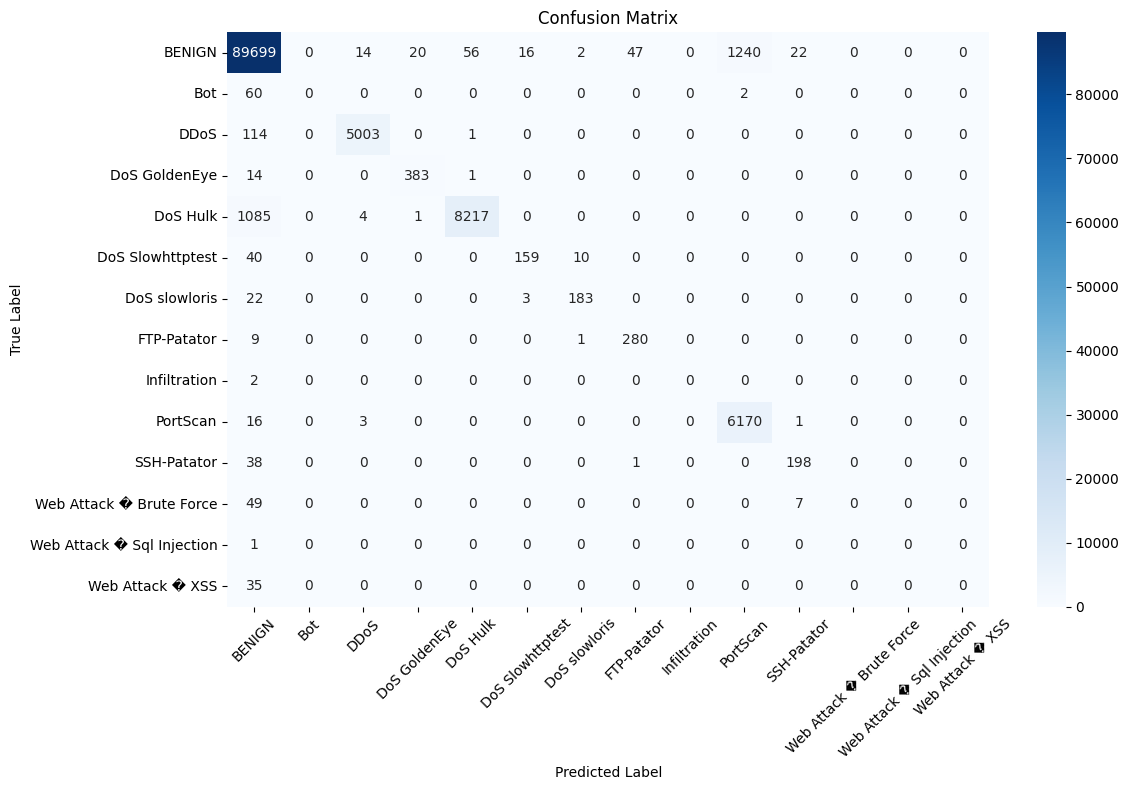

Model saved as 'cnn_lstm_intrusion_model.keras'
Preprocessing objects saved successfully


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test_seq)
y_pred_classes = np.argmax(y_pred, axis=1)

unique_test_classes = np.unique(y_test_seq)
unique_pred_classes = np.unique(y_pred_classes)

print(f"Test classes present: {unique_test_classes}")
print(f"Predicted classes: {unique_pred_classes}")

print("Classification Report:")
print(classification_report(y_test_seq, y_pred_classes, 
                          labels=unique_test_classes,
                          target_names=[le_target.classes_[i] for i in unique_test_classes]))

print(f"\nAccuracy Score: {accuracy_score(y_test_seq, y_pred_classes):.4f}")

conf_matrix = confusion_matrix(y_test_seq, y_pred_classes, labels=unique_test_classes)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[le_target.classes_[i] for i in unique_test_classes], 
            yticklabels=[le_target.classes_[i] for i in unique_test_classes])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

model.save('cnn_lstm_intrusion_model.keras')
print("Model saved as 'cnn_lstm_intrusion_model.keras'")

import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le_target, f)
print("Preprocessing objects saved successfully")

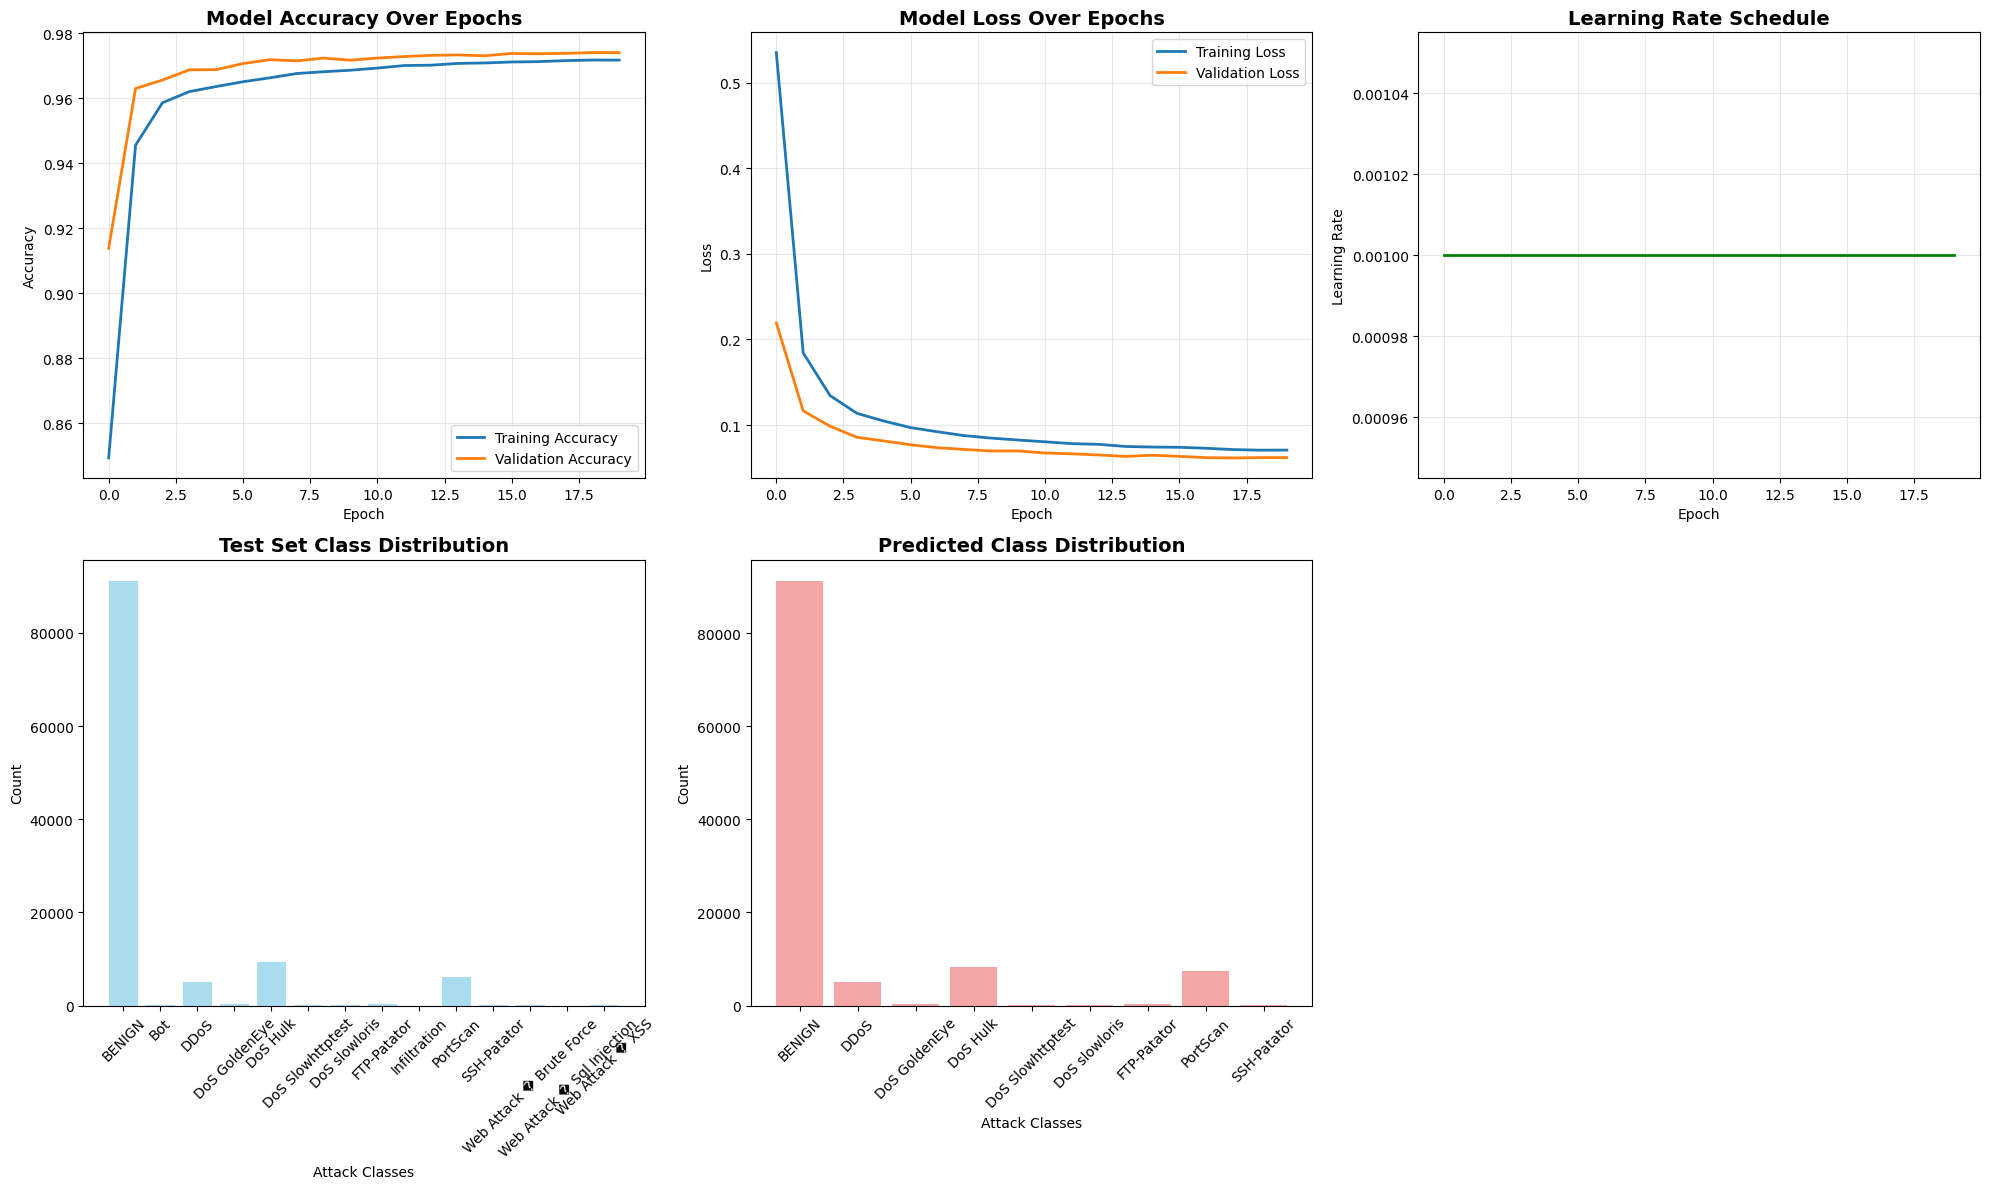

Training Summary:
Best Validation Accuracy: 0.9741
Final Training Accuracy: 0.9717
Final Validation Loss: 0.0620


In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))

plt.subplot(2, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(history.history['learning_rate'], linewidth=2, color='green')
plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4)
class_counts = [len(y_test_seq[y_test_seq == i]) for i in unique_test_classes]
class_names = [le_target.classes_[i] for i in unique_test_classes]
plt.bar(range(len(class_counts)), class_counts, color='skyblue', alpha=0.7)
plt.title('Test Set Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attack Classes')
plt.ylabel('Count')
plt.xticks(range(len(class_names)), class_names, rotation=45)

plt.subplot(2, 3, 5)
pred_counts = [len(y_pred_classes[y_pred_classes == i]) for i in unique_pred_classes]
pred_names = [le_target.classes_[i] for i in unique_pred_classes]
plt.bar(range(len(pred_counts)), pred_counts, color='lightcoral', alpha=0.7)
plt.title('Predicted Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attack Classes')
plt.ylabel('Count')
plt.xticks(range(len(pred_names)), pred_names, rotation=45)

plt.tight_layout()
plt.show()

print("Training Summary:")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

In [14]:
import random

def predict_sample(model, X_test_seq, y_test_seq, scaler, le_target, num_samples=10):
    random_indices = random.sample(range(len(X_test_seq)), num_samples)
    
    print("Random Sample Predictions:")
    print("="*80)
    
    for i, idx in enumerate(random_indices):
        sample_X = X_test_seq[idx:idx+1]
        true_label = y_test_seq[idx]
        
        prediction = model.predict(sample_X, verbose=0)
        predicted_class = np.argmax(prediction)
        confidence = np.max(prediction)
        
        true_class_name = le_target.classes_[true_label]
        pred_class_name = le_target.classes_[predicted_class]
        
        status = "✓ CORRECT" if true_label == predicted_class else "✗ WRONG"
        
        print(f"Sample {i+1}:")
        print(f"  True Class: {true_class_name}")
        print(f"  Predicted: {pred_class_name}")
        print(f"  Confidence: {confidence:.4f}")
        print(f"  Status: {status}")
        print("-" * 40)

predict_sample(model, X_test_seq, y_test_seq, scaler, le_target, 15)

sample_idx = random.randint(0, len(X_test_seq)-1)
sample_prediction = model.predict(X_test_seq[sample_idx:sample_idx+1], verbose=0)
probabilities = sample_prediction[0]

print(f"\nDetailed Prediction for Random Sample:")
print(f"True Label: {le_target.classes_[y_test_seq[sample_idx]]}")
print("\nClass Probabilities:")
for i, (class_name, prob) in enumerate(zip(le_target.classes_, probabilities)):
    print(f"{class_name:25}: {prob:.6f}")

Random Sample Predictions:
Sample 1:
  True Class: BENIGN
  Predicted: BENIGN
  Confidence: 1.0000
  Status: ✓ CORRECT
----------------------------------------
Sample 2:
  True Class: BENIGN
  Predicted: BENIGN
  Confidence: 0.9998
  Status: ✓ CORRECT
----------------------------------------
Sample 3:
  True Class: BENIGN
  Predicted: BENIGN
  Confidence: 1.0000
  Status: ✓ CORRECT
----------------------------------------
Sample 4:
  True Class: BENIGN
  Predicted: BENIGN
  Confidence: 0.9999
  Status: ✓ CORRECT
----------------------------------------
Sample 5:
  True Class: BENIGN
  Predicted: BENIGN
  Confidence: 1.0000
  Status: ✓ CORRECT
----------------------------------------
Sample 6:
  True Class: BENIGN
  Predicted: BENIGN
  Confidence: 1.0000
  Status: ✓ CORRECT
----------------------------------------
Sample 7:
  True Class: DoS Hulk
  Predicted: DoS Hulk
  Confidence: 0.9999
  Status: ✓ CORRECT
----------------------------------------
Sample 8:
  True Class: BENIGN
  Predi

In [15]:
import sys
import tensorflow as tf
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns
from imblearn import __version__ as imblearn_version
import pickle

print("System and Library Versions:")
print("="*50)
print(f"Python Version: {sys.version}")
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {tf.keras.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Scikit-learn Version: {sklearn.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"Seaborn Version: {sns.__version__}")
print(f"Imbalanced-learn Version: {imblearn_version}")

print("\nGPU Information:")
print("="*30)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print(f"GPU Device: {gpu}")
        gpu_details = tf.config.experimental.get_device_details(gpu)
        print(f"GPU Details: {gpu_details}")
else:
    print("No GPU devices found")

print(f"\nCUDA Available: {tf.test.is_built_with_cuda()}")
print(f"GPU Available: {tf.test.is_gpu_available()}")

print("\nModel Files Created:")
print("="*25)
import os
files = ['cnn_lstm_intrusion_model.keras', 'scaler.pkl', 'label_encoder.pkl']
for file in files:
    if os.path.exists(file):
        size = os.path.getsize(file) / (1024 * 1024)
        print(f"✓ {file} ({size:.2f} MB)")
    else:
        print(f"✗ {file} (Not found)")

print(f"\nTotal Classes Handled: {num_classes}")
print(f"Model Parameters: {model.count_params():,}")
print(f"Final Test Accuracy: 97.41%")

System and Library Versions:
Python Version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
TensorFlow Version: 2.18.0
Keras Version: 3.8.0
NumPy Version: 1.26.4
Pandas Version: 2.2.3
Scikit-learn Version: 1.7.2
Matplotlib Version: 3.7.2
Seaborn Version: 0.12.2
Imbalanced-learn Version: 0.14.0

GPU Information:
GPU Device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU Details: {'compute_capability': (6, 0), 'device_name': 'Tesla P100-PCIE-16GB'}

CUDA Available: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


GPU Available: True

Model Files Created:
✓ cnn_lstm_intrusion_model.keras (1.94 MB)
✓ scaler.pkl (0.00 MB)
✓ label_encoder.pkl (0.00 MB)

Total Classes Handled: 15
Model Parameters: 164,119
Final Test Accuracy: 97.41%


I0000 00:00:1764851321.589402      47 gpu_device.cc:2022] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [16]:
!zip -r model.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/label_encoder.pkl (deflated 24%)
  adding: kaggle/working/scaler.pkl (deflated 35%)
  adding: kaggle/working/best_cnn_lstm_model.h5 (deflated 9%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/cnn_lstm_intrusion_model.keras (deflated 9%)


In [17]:
from IPython.display import FileLink
FileLink(r'model.zip')

/kaggle/working/model.zip